Data source : https://www.kaggle.com/c/home-credit-default-risk/data

But notebook : Feature Engineering / Reduction

- utiliser les donnes agrégées précédemment
- réduire le dataframe (optimisation de futurs temps de calcul / temps de modélisation) tout en ayant le moins de données manquantes dans les features restantes
   - verification des types et choix de types plus avantageux en poids si possible
   - entrainement sur différents modèles et extraction des features notables via SHAPE ou autre (knn most important features)
   - éviter de "créer" des informations ex-nihilo avec de l'inputing : favoriser la sélection / suppression en préservant au mieux l'intégrité des données

# Imports

## libraries

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os

import numpy as np
import pandas as pd
import inspect

import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# import utils from parent directory
import sys
from pathlib import Path
parent_dir = str(Path().resolve().parents[1])
sys.path.insert(0, parent_dir)

import utils.UVA as UVA
import utils.MVA as MVA
import utils.PCA as PCA

In [4]:
import gc
import time
from contextlib import contextmanager
import re

In [5]:
# https://numpy.org/doc/stable/release/2.0.0-notes.html#representation-of-numpy-scalars-changed
np.set_printoptions(legacy='1.21')

In [6]:
import mlflow
import mlflow.lightgbm
import mlflow.xgboost
import mlflow.sklearn

from mlflow import MlflowClient
from mlflow.models.signature import infer_signature
from pprint import pprint

In [7]:
from sklearn.impute import KNNImputer
from sklearn.impute import SimpleImputer

import lightgbm as lgb
from lightgbm import LGBMClassifier
from sklearn import model_selection

from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import roc_auc_score, roc_curve, accuracy_score,fbeta_score, make_scorer

from sklearn.ensemble import RandomForestClassifier

In [8]:
import xgboost as xgb
import shap

## data

In [9]:
csv_path_output = '../data/output/'
file_name = 'df_reduced.csv'

df = pd.read_csv(f'{csv_path_output + file_name}', encoding='ISO-8859-1')
df.drop(df.filter(regex="Unname"),axis=1, inplace=True)

In [10]:
df.shape

(356251, 41)

In [11]:
df.head()

,EXT_SOURCE_2,EXT_SOURCE_3,EXT_SOURCE_1,DAYS_EMPLOYED,INSTAL_DPD_MEAN,CODE_GENDER,PAYMENT_RATE,DAYS_EMPLOYED_PERC,DAYS_BIRTH,OWN_CAR_AGE,...,INSTAL_PAYMENT_PERC_MEAN,INSTAL_DAYS_ENTRY_PAYMENT_MEAN,PREV_APP_CREDIT_PERC_MIN,INSTAL_AMT_PAYMENT_MIN,BURO_CREDIT_ACTIVE_Closed_MEAN,DAYS_REGISTRATION,APPROVED_AMT_ANNUITY_MAX,INSTAL_AMT_PAYMENT_MEAN,ACTIVE_DAYS_CREDIT_ENDDATE_MEAN,TARGET
0,0.262949,0.139376,0.083037,-637.0,0.000000,0,0.060749,0.067329,-9461,NaN,...,1.000000,-315.42105,1.000000,9251.775,0.75,-3648.0,9251.775,11559.247,780.0,1.0
1,0.622246,NaN,0.311267,-1188.0,0.000000,1,0.027598,0.070862,-16765,NaN,...,1.000000,-1385.32000,0.868825,6662.970,0.75,-1186.0,98356.990,64754.586,1216.0,0.0
2,0.555912,0.729567,NaN,-225.0,0.000000,0,0.050000,0.011814,-19046,26.0,...,1.000000,-761.66670,1.207699,5357.250,1.00,-4260.0,5357.250,7096.155,NaN,0.0
3,0.650442,NaN,NaN,-3039.0,0.000000,1,0.094941,0.159905,-19005,NaN,...,1.000000,-271.62500,0.759418,2482.920,NaN,-9833.0,39954.510,62947.090,NaN,0.0
4,0.322738,NaN,NaN,-3038.0,0.954545,0,0.042623,0.152418,-19932,NaN,...,0.954545,-1032.24240,0.791139,0.180,1.00,-4311.0,22678.785,12214.061,NaN,0.0


# Explo

## Valeurs manquantes

In [12]:
# https://medium.com/@kavyasree42/how-to-handle-missing-data-in-python-simple-to-advanced-techniques-machine-learning-brain-ffae3c1a694f

In [13]:
@contextmanager
def timer(title):
    t0 = time.time()
    yield
    print("{} - done in {:.0f}s".format(title, time.time() - t0))
    
# Function to calculate missing values by column
def missing_values_table(df):
    # Taux de valeurs manquantes :
    print("Taux de valeurs manquantes dans le df avant imputation :" , round(df.isna().mean().mean(),4))
    # Total missing values
    mis_val = df.isnull().sum()
    
    # Percentage of missing values
    mis_val_percent = 100 * df.isnull().sum() / len(df)
    
    # Make a table with the results
    mis_val_table = pd.concat([mis_val, mis_val_percent], axis=1)
    
    # Rename the columns
    mis_val_table_ren_columns = mis_val_table.rename(columns = {0 : 'Missing Values', 1 : '% of Total Values'})
    
    # Sort the table by percentage of missing descending
    mis_val_table_ren_columns = mis_val_table_ren_columns[
        mis_val_table_ren_columns.iloc[:,1] != 0].sort_values(
        '% of Total Values', ascending=False).round(1)
    
    # Print some summary information
    print ("Your selected dataframe has " + str(df.shape[1]) + " columns.\n"
           "There are " + str(mis_val_table_ren_columns.shape[0]) +
           " columns that have missing values.")
    
    # Return the dataframe with missing information
    return mis_val_table_ren_columns

In [14]:
with timer ("Imputation des valeurs manquantes") :
     #  Statistiques sur les valeurs manquantes :
    missing_values = missing_values_table(df)
    df.replace([np.inf, -np.inf], np.nan, inplace=True)
    
    # Séparation du jeu de données en jeu de  training/validation et jeu de test
    train_df = df[df['TARGET'].notnull()] # partie du jeu de données qui contient une target
    test_df = df[df['TARGET'].isnull()] # partie du jeu de données qui n'a pas de target
    print(train_df.shape, test_df.shape)
    train_df["TARGET"].value_counts()/train_df.shape[0]
    
    # Taux de valeurs manquantes :
    print("Taux de valeurs manquantes dans jeu de train avant imputation :" , round(train_df.isna().mean().mean(),4))
    print("Taux de valeurs manquantes dans jeu de test avant imputation :" , round(test_df.isna().mean().mean(),4))

Taux de valeurs manquantes dans le df avant imputation : 0.1343
Your selected dataframe has 41 columns.
There are 35 columns that have missing values.
(307507, 41) (48744, 41)
Taux de valeurs manquantes dans jeu de train avant imputation : 0.1336
Taux de valeurs manquantes dans jeu de test avant imputation : 0.1391
Imputation des valeurs manquantes - done in 0s


# Typage

In [15]:
df.head()

,EXT_SOURCE_2,EXT_SOURCE_3,EXT_SOURCE_1,DAYS_EMPLOYED,INSTAL_DPD_MEAN,CODE_GENDER,PAYMENT_RATE,DAYS_EMPLOYED_PERC,DAYS_BIRTH,OWN_CAR_AGE,...,INSTAL_PAYMENT_PERC_MEAN,INSTAL_DAYS_ENTRY_PAYMENT_MEAN,PREV_APP_CREDIT_PERC_MIN,INSTAL_AMT_PAYMENT_MIN,BURO_CREDIT_ACTIVE_Closed_MEAN,DAYS_REGISTRATION,APPROVED_AMT_ANNUITY_MAX,INSTAL_AMT_PAYMENT_MEAN,ACTIVE_DAYS_CREDIT_ENDDATE_MEAN,TARGET
0,0.262949,0.139376,0.083037,-637.0,0.000000,0,0.060749,0.067329,-9461,NaN,...,1.000000,-315.42105,1.000000,9251.775,0.75,-3648.0,9251.775,11559.247,780.0,1.0
1,0.622246,NaN,0.311267,-1188.0,0.000000,1,0.027598,0.070862,-16765,NaN,...,1.000000,-1385.32000,0.868825,6662.970,0.75,-1186.0,98356.990,64754.586,1216.0,0.0
2,0.555912,0.729567,NaN,-225.0,0.000000,0,0.050000,0.011814,-19046,26.0,...,1.000000,-761.66670,1.207699,5357.250,1.00,-4260.0,5357.250,7096.155,NaN,0.0
3,0.650442,NaN,NaN,-3039.0,0.000000,1,0.094941,0.159905,-19005,NaN,...,1.000000,-271.62500,0.759418,2482.920,NaN,-9833.0,39954.510,62947.090,NaN,0.0
4,0.322738,NaN,NaN,-3038.0,0.954545,0,0.042623,0.152418,-19932,NaN,...,0.954545,-1032.24240,0.791139,0.180,1.00,-4311.0,22678.785,12214.061,NaN,0.0


In [16]:
df.dtypes

EXT_SOURCE_2                           float64
EXT_SOURCE_3                           float64
EXT_SOURCE_1                           float64
DAYS_EMPLOYED                          float64
INSTAL_DPD_MEAN                        float64
CODE_GENDER                              int64
PAYMENT_RATE                           float64
DAYS_EMPLOYED_PERC                     float64
DAYS_BIRTH                               int64
OWN_CAR_AGE                            float64
PREV_CNT_PAYMENT_MEAN                  float64
AMT_GOODS_PRICE                        float64
AMT_ANNUITY                            float64
ANNUITY_INCOME_PERC                    float64
INSTAL_AMT_PAYMENT_SUM                 float64
APPROVED_AMT_DOWN_PAYMENT_MAX          float64
BURO_AMT_CREDIT_SUM_DEBT_MEAN          float64
NAME_EDUCATION_TYPE_Highereducation      int64
AMT_CREDIT                             float64
CC_CNT_DRAWINGS_ATM_CURRENT_MEAN       float64
ACTIVE_DAYS_CREDIT_MAX                 float64
BURO_DAYS_CRE

In [17]:
# Vérification des dtypes actuels
print("Dtypes initiaux :")
print(df.dtypes.value_counts())
print("\nInfos avant conversion :")
print(df.info())
df_memory_usage_gb = df.memory_usage(deep=True).sum() / (1024 ** 3)
print(f'{df_memory_usage_gb} Gb')

# Analyse de la distribution des données
for column in df.columns:
    if df[column].dtype == 'int64':
        min_val, max_val = df[column].min(), df[column].max()
        if min_val >= np.iinfo(np.int8).min and max_val <= np.iinfo(np.int8).max:
            df[column] = df[column].astype(np.int8)
        elif min_val >= np.iinfo(np.int16).min and max_val <= np.iinfo(np.int16).max:
            df[column] = df[column].astype(np.int16)
        elif min_val >= np.iinfo(np.int32).min and max_val <= np.iinfo(np.int32).max:
            df[column] = df[column].astype(np.int32)
    elif df[column].dtype == 'float64':
        df[column] = df[column].astype(np.float32)

# Vérification des dtypes après conversion
print("\nDtypes après conversion :")
print(df.dtypes.value_counts())
print("\nInfos sur le DataFrame :")
print(df.info())
df_memory_usage_gb = df.memory_usage(deep=True).sum() / (1024 ** 3)
print(f'{df_memory_usage_gb} Gb')

Dtypes initiaux :
float64    37
int64       4
dtype: int64

Infos avant conversion :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 356251 entries, 0 to 356250
Data columns (total 41 columns):
 #   Column                               Non-Null Count   Dtype  
---  ------                               --------------   -----  
 0   EXT_SOURCE_2                         355583 non-null  float64
 1   EXT_SOURCE_3                         286618 non-null  float64
 2   EXT_SOURCE_1                         162343 non-null  float64
 3   DAYS_EMPLOYED                        291603 non-null  float64
 4   INSTAL_DPD_MEAN                      339583 non-null  float64
 5   CODE_GENDER                          356251 non-null  int64  
 6   PAYMENT_RATE                         356215 non-null  float64
 7   DAYS_EMPLOYED_PERC                   291603 non-null  float64
 8   DAYS_BIRTH                           356251 non-null  int64  
 9   OWN_CAR_AGE                          121012 non-null  float64


In [18]:
df['TARGET'].value_counts(dropna=False)

0.0    282682
NaN     48744
1.0     24825
Name: TARGET, dtype: int64

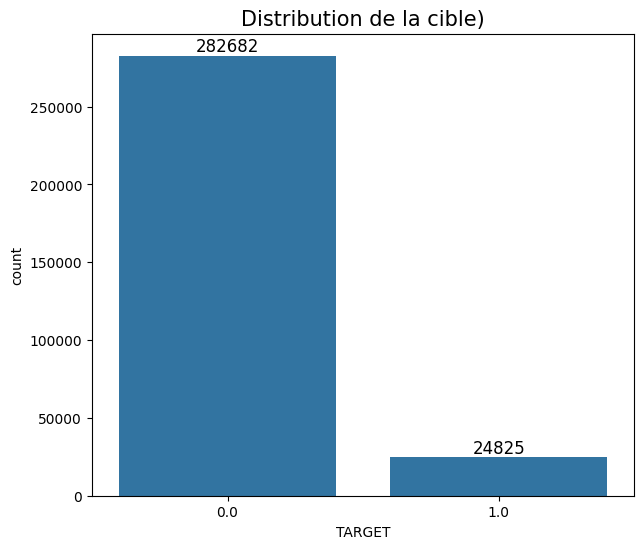

In [19]:
fig,ax=plt.subplots(figsize=(7,6))
plt.title("Distribution de la cible)", fontsize=15)
sns.countplot(x='TARGET', data=df)
for container in ax.containers:
    ax.bar_label(container,size=12,fmt='%.0f')
plt.show()

In [20]:
# Séparer les données en X_train et X_test
X_train = df[df['TARGET'].notna()]
X_test = df[df['TARGET'].isna()]

print("Dimensions de X_train :", X_train.shape)
print("Dimensions de X_test :", X_test.shape)

Dimensions de X_train : (307507, 41)
Dimensions de X_test : (48744, 41)


In [21]:
X_train['TARGET'].value_counts(dropna=False)

0.0    282682
1.0     24825
Name: TARGET, dtype: int64

In [22]:
# Vérifier les valeurs manquantes dans X_train
missing_values = X_train.isna().sum()

# Afficher les valeurs manquantes par colonne
print("Valeurs manquantes dans X_train :")
print(missing_values.sum())

Valeurs manquantes dans X_train :
1684233


In [23]:
# Calculer le pourcentage de valeurs manquantes par colonne
missing_percentages = X_train.isna().mean() * 100

# Créer un DataFrame pour afficher les résultats
missing_table = pd.DataFrame({
    'Feature': missing_percentages.index,
    'Missing Percentage': missing_percentages.values
}).sort_values(by='Missing Percentage', ascending=False)

# Ajouter une ligne pour le total
total_missing_percentage = missing_percentages.mean()
missing_table = pd.concat([missing_table, pd.DataFrame({
    'Feature': ['Total'],
    'Missing Percentage': [total_missing_percentage]
})], ignore_index=True)

# Afficher le tableau
pd.set_option('display.max_rows', None)
print("Pourcentage de valeurs manquantes par feature :")
print(missing_table)

Pourcentage de valeurs manquantes par feature :
                                Feature  Missing Percentage
0      CC_CNT_DRAWINGS_ATM_CURRENT_MEAN           80.117526
1                           OWN_CAR_AGE           65.991018
2                          EXT_SOURCE_1           56.381156
3                        TOTALAREA_MODE           48.268820
4        ACTIVE_DAYS_CREDIT_ENDDATE_MAX           32.299753
5       ACTIVE_DAYS_CREDIT_ENDDATE_MEAN           32.299753
6                ACTIVE_DAYS_CREDIT_MAX           29.385022
7                          EXT_SOURCE_3           19.825565
8                    DAYS_EMPLOYED_PERC           18.007395
9                         DAYS_EMPLOYED           18.007395
10        BURO_AMT_CREDIT_SUM_DEBT_MEAN           16.708563
11       BURO_CREDIT_ACTIVE_Closed_MEAN           14.315121
12                 BURO_DAYS_CREDIT_MAX           14.315121
13                BURO_DAYS_CREDIT_MEAN           14.315121
14        APPROVED_AMT_DOWN_PAYMENT_MAX           11

In [24]:
def missing_values_count(df):
    # Calculer le pourcentage de valeurs manquantes par colonne
    missing_percentages = df.isna().mean() * 100
    
    # Créer des bins pour les pourcentages de valeurs manquantes
    bins = [0, 0.01, 20, 40, 60, 100]  # 0%, 0-20%, 20-40%, 40-60%, 60-100%
    labels = ['0%', '0-20%', '20-40%', '40-60%', '60-100%']
    
    # Classer les caractéristiques dans les bins
    missing_bins = pd.cut(missing_percentages, bins=bins, labels=labels, right=False)
    
    # Compter le nombre de variables par bin
    bin_counts = missing_bins.value_counts().sort_index()
    
    # Calculer le pourcentage de variables dans chaque bin par rapport au total
    total_variables = len(missing_percentages)
    bin_percentages = (bin_counts / total_variables) * 100
    
    # Créer un DataFrame pour afficher les résultats
    bin_summary = pd.DataFrame({
        'Number of Variables': bin_counts,
        'Percentage of Total': bin_percentages
    })
    
    # Afficher le nombre de variables par bin et leur pourcentage par rapport au total
    print("Nombre de variables par bin de valeurs manquantes et leur pourcentage par rapport au total :")
    print(bin_summary)

In [25]:
missing_values_count(df)

Nombre de variables par bin de valeurs manquantes et leur pourcentage par rapport au total :
         Number of Variables  Percentage of Total
0%                         6            14.634146
0-20%                     28            68.292683
20-40%                     3             7.317073
40-60%                     2             4.878049
60-100%                    2             4.878049


# Modélisations + MLflow

In [26]:
# Séparer les caractéristiques et la cible
X = X_train.drop(columns=['TARGET'])
y = X_train['TARGET']

# Remplacer les valeurs infinies par NaN ___ "XGBoostError : Check failed: valid: Input data contains `inf` or a value too large, while `missing` is not set to `inf`"
X.replace([np.inf, -np.inf], np.nan, inplace=True)

# Remplacer les NaN par la moyenne de la colonne
#X.fillna(X.mean(), inplace=True)

In [27]:
X.head()

,EXT_SOURCE_2,EXT_SOURCE_3,EXT_SOURCE_1,DAYS_EMPLOYED,INSTAL_DPD_MEAN,CODE_GENDER,PAYMENT_RATE,DAYS_EMPLOYED_PERC,DAYS_BIRTH,OWN_CAR_AGE,...,TOTALAREA_MODE,INSTAL_PAYMENT_PERC_MEAN,INSTAL_DAYS_ENTRY_PAYMENT_MEAN,PREV_APP_CREDIT_PERC_MIN,INSTAL_AMT_PAYMENT_MIN,BURO_CREDIT_ACTIVE_Closed_MEAN,DAYS_REGISTRATION,APPROVED_AMT_ANNUITY_MAX,INSTAL_AMT_PAYMENT_MEAN,ACTIVE_DAYS_CREDIT_ENDDATE_MEAN
0,0.262949,0.139376,0.083037,-637.0,0.000000,0,0.060749,0.067329,-9461,NaN,...,0.0149,1.000000,-315.421051,1.000000,9251.775391,0.75,-3648.0,9251.775391,11559.247070,780.0
1,0.622246,NaN,0.311267,-1188.0,0.000000,1,0.027598,0.070862,-16765,NaN,...,0.0714,1.000000,-1385.319946,0.868825,6662.970215,0.75,-1186.0,98356.992188,64754.585938,1216.0
2,0.555912,0.729567,NaN,-225.0,0.000000,0,0.050000,0.011814,-19046,26.0,...,NaN,1.000000,-761.666687,1.207699,5357.250000,1.00,-4260.0,5357.250000,7096.154785,NaN
3,0.650442,NaN,NaN,-3039.0,0.000000,1,0.094941,0.159905,-19005,NaN,...,NaN,1.000000,-271.625000,0.759418,2482.919922,NaN,-9833.0,39954.511719,62947.089844,NaN
4,0.322738,NaN,NaN,-3038.0,0.954545,0,0.042623,0.152418,-19932,NaN,...,NaN,0.954545,-1032.242432,0.791139,0.180000,1.00,-4311.0,22678.785156,12214.060547,NaN


In [28]:
y.head()

0    1.0
1    0.0
2    0.0
3    0.0
4    0.0
Name: TARGET, dtype: float32

In [29]:
# Diviser les données en ensembles d'entraînement et de test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

## test MLflow

In [30]:
# Définir les paramètres pour chaque modèle
xgb_params = {
    'objective': 'binary:logistic',
    'eval_metric': 'logloss',
    'max_depth': 3,
    'learning_rate': 0.1,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'seed': 42
}

lgb_params = {
    'objective': 'binary',
    'metric': 'binary_logloss',
    'max_depth': 3,
    'learning_rate': 0.1,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'seed': 42
}

rf_params = {
    'n_estimators': 100,
    'max_depth': 3,
    'random_state': 42
}

In [31]:
# Fonction pour entraîner et suivre un modèle avec MLflow
def train_and_log_model(model_name, model, params):
    with mlflow.start_run():
        # Entraîner le modèle
        model.fit(X_train, y_train)

        # Prédire les probabilités pour la classe positive
        y_pred_proba = model.predict_proba(X_test)[:, 1]

        # Calculer le score ROC-AUC
        auc_roc = roc_auc_score(y_test, y_pred_proba)

        # Journaliser les paramètres et les métriques
        mlflow.log_params(params)
        mlflow.log_metric("auc_roc", auc_roc)

        # Prendre un exemple d'entrée pour la signature du modèle
        input_example = X_train.head(1)

        # Journaliser le modèle avec un exemple d'entrée
        if model_name == "XGBoost":
            mlflow.xgboost.log_model(model, "model", input_example=input_example)
        elif model_name == "LightGBM":
            mlflow.lightgbm.log_model(model, "model", input_example=input_example)
        elif model_name == "RandomForest":
            mlflow.sklearn.log_model(model, "model", input_example=input_example)

        print(f"{model_name} - AUC-ROC: {auc_roc}")


In [32]:
# Entraîner et suivre chaque modèle
train_and_log_model("XGBoost", xgb.XGBClassifier(**xgb_params), xgb_params)

XGBoost - AUC-ROC: 0.7680761311243329


In [33]:
train_and_log_model("LightGBM", lgb.LGBMClassifier(**lgb_params), lgb_params)

[LightGBM] [Info] Number of positive: 17383, number of negative: 197871
[LightGBM] [Warning] Auto-choosing col-wise multi-threading, the overhead of testing was 0.035726 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 9268
[LightGBM] [Info] Number of data points in the train set: 215254, number of used features: 40
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080756 -> initscore=-2.432123
[LightGBM] [Info] Start training from score -2.432123
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
LightGBM - AUC-ROC: 0.7686922654911225


In [34]:
train_and_log_model("RandomForest", RandomForestClassifier(**rf_params), rf_params)

RandomForest - AUC-ROC: 0.7310888965876166
